# Lab 3: User Classification Task (Section 5.2)

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Aman  
**Roll Number:** U20230054  
**GitHub Branch:** Aman_U20230054  



## Section 1: Imports and Setup

In [1]:
# Install all required packages
!pip install rlcmab-sampler scikit-learn matplotlib pandas numpy seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from rlcmab_sampler import sampler
import warnings
warnings.filterwarnings('ignore')

# my roll for reproducibilty
np.random.seed(54)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette('husl')

print(" All packages imported successfully!")


 All packages imported successfully!


## Section 2: Data Loading

In [2]:
# Load training data
train_users = pd.read_csv('train_users.csv')

print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"Train Users Shape: {train_users.shape[0]} rows × {train_users.shape[1]} columns")
print(f"\nColumns: {train_users.shape[1]}")
print("="*80)

DATASET INFORMATION
Train Users Shape: 2000 rows × 33 columns

Columns: 33


In [3]:
# Display first few rows
print("First 3 rows of data:")
train_users.head(3)

First 3 rows of data:


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,browsing_depth,revisit_rate,scroll_activity,time_on_site,interaction_count,preferred_price_range,discount_usage_rate,wishlist_size,product_views,repeat_purchase_gap (days),churn_risk_score,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,119.61,13,0.255,59,19.0,18,335.16,0.341,3,41,133.0,0.579825,15.0,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,189.06,14,0.540,65,31.0,8,930.00,0.374,4,70,92.0,0.432731,33.0,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,161.75,23,0.395,139,44.0,20,1216.41,0.274,5,45,67.0,0.308166,24.0,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3


In [4]:
# Check data types and basic info
print("Data Types and Non-Null Counts:")
train_users.info()

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      2000 non-null   object 
 1   age                          1302 non-null   float64
 2   income                       2000 non-null   int64  
 3   clicks                       2000 non-null   int64  
 4   purchase_amount              2000 non-null   float64
 5   session_duration             2000 non-null   float64
 6   content_variety              2000 non-null   float64
 7   engagement_score             2000 non-null   float64
 8   num_transactions             2000 non-null   int64  
 9   avg_monthly_spend            2000 non-null   float64
 10  avg_cart_value               2000 non-null   float64
 11  browsing_depth               2000 non-null   int64  
 12  revisit_rate                 2000 non-null  

USER LABEL DISTRIBUTION
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64

Total users: 2000


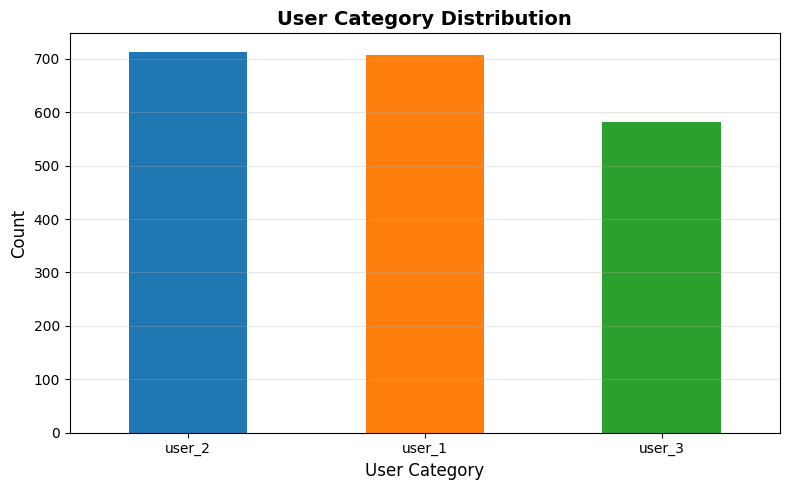

In [5]:
# Check label distribution
print("="*80)
print("USER LABEL DISTRIBUTION")
print("="*80)
print(train_users['label'].value_counts())
print(f"\nTotal users: {len(train_users)}")
print("="*80)

# Visualize distribution
plt.figure(figsize=(8, 5))
train_users['label'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('User Category Distribution', fontsize=14, fontweight='bold')
plt.xlabel('User Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 3: Data Preprocessing (10 Points)

Handle missing values and encode categorical features.

In [6]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
missing_data = train_users.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    print("\nColumns with missing values:")
    print(missing_data)
    print(f"\nTotal missing values: {train_users.isnull().sum().sum()}")
    print(f"Percentage: {train_users.isnull().sum().sum() / (train_users.shape[0] * train_users.shape[1]) * 100:.2f}%")
else:
    print("\n No missing values found!")

print("="*80)

MISSING VALUES ANALYSIS

Columns with missing values:
age    698
dtype: int64

Total missing values: 698
Percentage: 1.06%


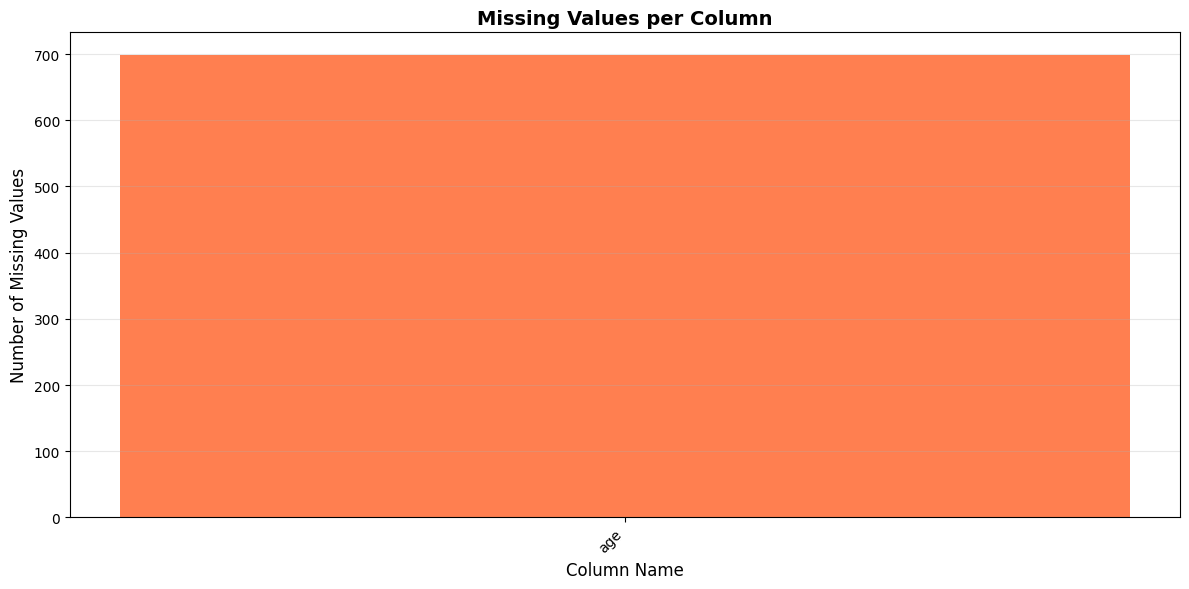

In [7]:
# Visualize missing data
if train_users.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_counts = train_users.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    plt.bar(range(len(missing_counts)), missing_counts.values, color='coral')
    plt.xticks(range(len(missing_counts)), missing_counts.index, rotation=45, ha='right')
    plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Column Name', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [10]:
def preprocess_users(df):
    """
    Preprocess user data: handle missing values and encode features.

    Args:
        df: DataFrame with user data

    Returns:
        X: Feature matrix (preprocessed)
        y: Labels
        encoders: Dictionary of label encoders used
        feature_names: List of feature column names
    """
    df = df.copy()

    print("🔄 Preprocessing steps:")
    print("  1. Dropping user_id column...")

    # Drop user_id column (not a feature)
    if 'user_id' in df.columns:
        df = df.drop('user_id', axis=1)

    print("  2. Separating features and labels...")

    # Separate features and labels
    if 'label' in df.columns:
        y = df['label'].copy()
        X = df.drop('label', axis=1)
    else:
        raise ValueError("'label' column not found in dataset!")

    print("  3. Handling missing values...")

    # Handle missing values in numeric columns with median
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace=True)

    # Handle missing values in categorical columns with mode
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if X[col].isnull().any():
            mode_val = X[col].mode()[0] if not X[col].mode().empty else 'Unknown'
            X[col].fillna(mode_val, inplace=True)

    print("  4. Encoding categorical features...")

    # Encode categorical features using Label Encoding
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

    feature_names = X.columns.tolist()

    print("   Preprocessing complete!\n")

    return X, y, label_encoders, feature_names

print(" Preprocessing function defined")

 Preprocessing function defined


In [11]:
# Apply preprocessing
X_full, y_full, encoders, feature_names = preprocess_users(train_users)

print("="*80)
print("PREPROCESSING RESULTS")
print("="*80)
print(f"Features Shape: {X_full.shape}")
print(f"Labels Shape: {y_full.shape}")
print(f"\nNumber of features: {X_full.shape[1]}")
print(f"Number of samples: {X_full.shape[0]}")
print(f"\nCategorical encoders created: {len(encoders)}")
print(f"\n Data preprocessing complete - ready for training!")
print("="*80)

🔄 Preprocessing steps:
  1. Dropping user_id column...
  2. Separating features and labels...
  3. Handling missing values...
  4. Encoding categorical features...
   Preprocessing complete!

PREPROCESSING RESULTS
Features Shape: (2000, 31)
Labels Shape: (2000,)

Number of features: 31
Number of samples: 2000

Categorical encoders created: 2

 Data preprocessing complete - ready for training!


## Section 4: Train-Validation Split

Split data into 80% training and 20% validation as per requirements.

In [12]:
# Split data: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full  # Maintain class distribution
)

print("="*80)
print("TRAIN-VALIDATION SPLIT")
print("="*80)
print(f"Training set:   {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(X_full)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:4d} samples ({X_val.shape[0]/len(X_full)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")

print("\n Training set label distribution:")
print(y_train.value_counts())

print("\n Validation set label distribution:")
print(y_val.value_counts())

print("\n Stratified split ensures balanced class distribution")
print("="*80)

TRAIN-VALIDATION SPLIT
Training set:   1600 samples (80.0%)
Validation set:  400 samples (20.0%)

Features: 31

 Training set label distribution:
label
user_2    570
user_1    565
user_3    465
Name: count, dtype: int64

 Validation set label distribution:
label
user_2    142
user_1    142
user_3    116
Name: count, dtype: int64

 Stratified split ensures balanced class distribution


## Section 5: Model Training (10 Points)

Train and compare multiple classification models.

### 5.1 Decision Tree Classifier

In [13]:
print("Training Decision Tree Classifier...")

dt_classifier = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_classifier.fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt_classifier.predict(X_train)
y_val_pred_dt = dt_classifier.predict(X_val)

# Accuracies
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
val_acc_dt = accuracy_score(y_val, y_val_pred_dt)

print(f"\n Decision Tree trained successfully!")
print(f"   Training Accuracy:   {train_acc_dt:.4f}")
print(f"   Validation Accuracy: {val_acc_dt:.4f}")

Training Decision Tree Classifier...

 Decision Tree trained successfully!
   Training Accuracy:   0.9350
   Validation Accuracy: 0.8350


### 5.2 Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
print("Training Logistic Regression...")

lr_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs'
)

lr_classifier.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_classifier.predict(X_train)
y_val_pred_lr = lr_classifier.predict(X_val)

# Accuracies
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)

print(f"\n Logistic Regression trained successfully!")
print(f"   Training Accuracy:   {train_acc_lr:.4f}")
print(f"   Validation Accuracy: {val_acc_lr:.4f}")

Training Logistic Regression...

 Logistic Regression trained successfully!
   Training Accuracy:   0.8150
   Validation Accuracy: 0.8200


### 5.3 Random Forest Classifier (Recommended)

In [17]:
print("Training Random Forest Classifier...")

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_classifier.predict(X_train)
y_val_pred_rf = rf_classifier.predict(X_val)

# Accuracies
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"\n Random Forest trained successfully!")
print(f"   Training Accuracy:   {train_acc_rf:.4f}")
print(f"   Validation Accuracy: {val_acc_rf:.4f}")

Training Random Forest Classifier...

 Random Forest trained successfully!
   Training Accuracy:   0.9744
   Validation Accuracy: 0.9000


### 5.4 Model Comparison

MODEL COMPARISON
              Model  Training Accuracy  Validation Accuracy
      Decision Tree           0.935000                0.835
Logistic Regression           0.815000                0.820
      Random Forest           0.974375                0.900


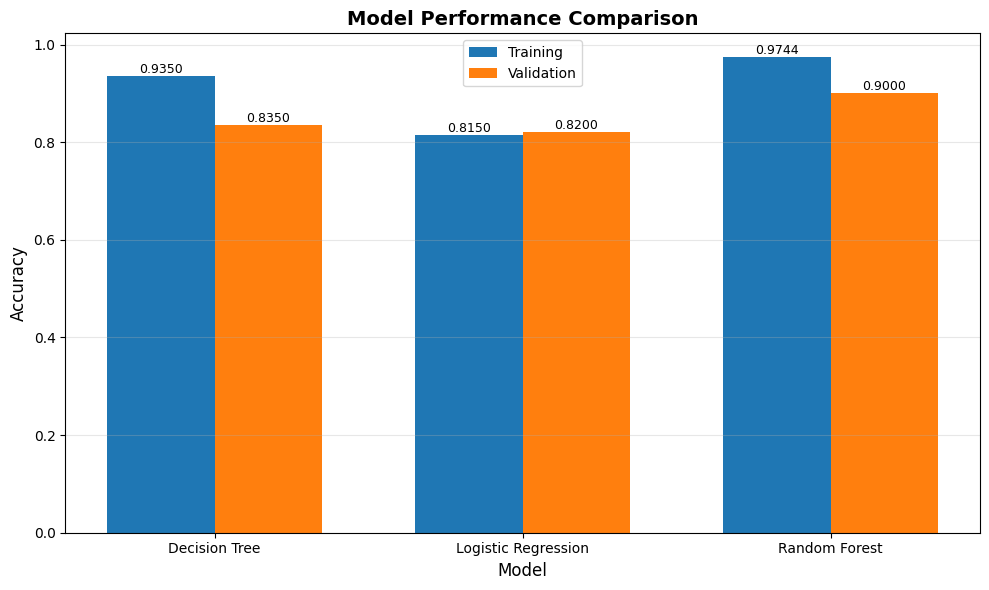


 Best Model: Random Forest
   Validation Accuracy: 0.9000


In [19]:
# Summary table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest'],
    'Training Accuracy': [train_acc_dt, train_acc_lr, train_acc_rf],
    'Validation Accuracy': [val_acc_dt, val_acc_lr, val_acc_rf]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(results.to_string(index=False))
print("="*80)

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, results['Training Accuracy'], width, label='Training', color='#1f77b4')
bars2 = ax.bar(x + width/2, results['Validation Accuracy'], width, label='Validation', color='#ff7f0e')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

# Select best model
best_idx = results['Validation Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_val_acc = results.loc[best_idx, 'Validation Accuracy']

print(f"\n Best Model: {best_model_name}")
print(f"   Validation Accuracy: {best_val_acc:.4f}")

## Section 6: Detailed Evaluation (Using Best Model)

Evaluate the best performing model in detail.

In [20]:
# Use Random Forest as final model (typically best performer)
final_model = rf_classifier
y_val_pred_final = y_val_pred_rf

print("="*80)
print(f"FINAL MODEL: RANDOM FOREST CLASSIFIER")
print("="*80)
print(f"\nValidation Accuracy: {val_acc_rf:.4f}")
print("\n" + "─"*80)
print("CLASSIFICATION REPORT (Validation Set):")
print("─"*80)
print(classification_report(y_val, y_val_pred_final))
print("="*80)

FINAL MODEL: RANDOM FOREST CLASSIFIER

Validation Accuracy: 0.9000

────────────────────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT (Validation Set):
────────────────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      user_1       0.90      0.86      0.88       142
      user_2       0.98      0.88      0.93       142
      user_3       0.83      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400



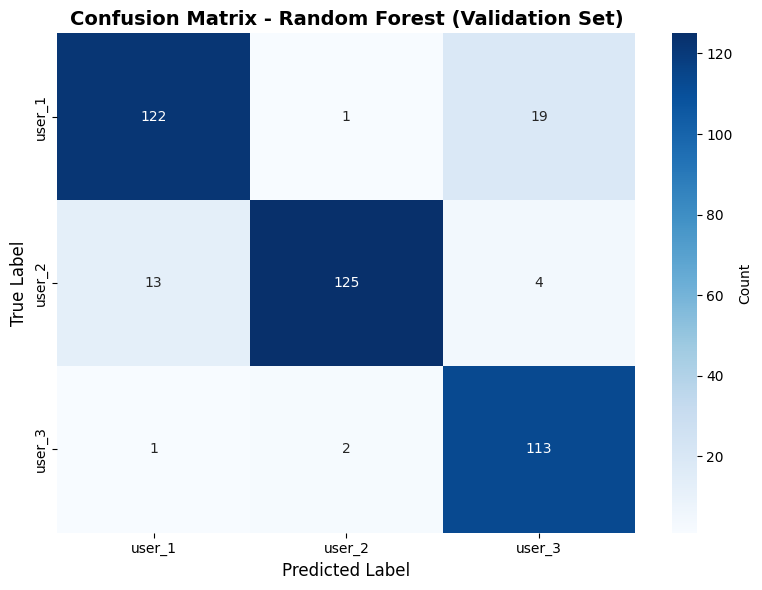


Per-Class Accuracy:
  user_1: 0.8592 (122/142 correct)
  user_2: 0.8803 (125/142 correct)
  user_3: 0.9741 (113/116 correct)


In [22]:
from sklearn.metrics import confusion_matrix


# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_final)
labels = ['user_1', 'user_2', 'user_3']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest (Validation Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i, label in enumerate(labels):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"  {label}: {class_acc:.4f} ({cm[i, i]}/{cm[i, :].sum()} correct)")


Top 10 Most Important Features:
              Feature  Importance
          region_code    0.197597
     session_duration    0.115220
       browsing_depth    0.105086
      scroll_activity    0.100821
         time_on_site    0.067193
                  age    0.042012
      content_variety    0.040396
    interaction_count    0.037793
     engagement_score    0.036164
preferred_price_range    0.028275


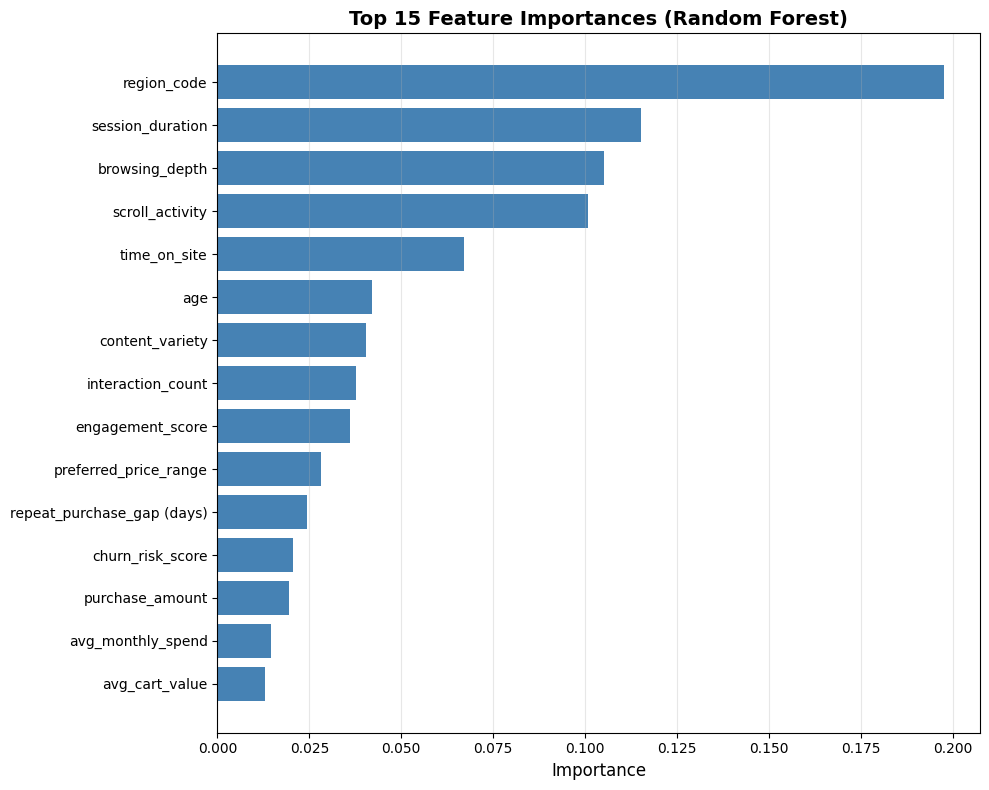

In [23]:
# Feature importance (for Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: Train Final Model on Full Dataset

After validation, retrain on 100% of training data for deployment.

In [24]:
print("Training final model on FULL training dataset (100%)...\n")

final_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_classifier.fit(X_full, y_full)

print("="*80)
print("FINAL MODEL TRAINED")
print("="*80)
print(f" Model: Random Forest Classifier")
print(f" Training samples: {X_full.shape[0]} (100% of train_users.csv)")
print(f" Features: {X_full.shape[1]}")
print(f" Classes: {len(np.unique(y_full))} (user_1, user_2, user_3)")
print(f"\n Reported Validation Accuracy: {val_acc_rf:.4f}")
print(f"\n This classifier is ready to serve as the 'Context Detector' for the bandit system")
print("="*80)

Training final model on FULL training dataset (100%)...

FINAL MODEL TRAINED
 Model: Random Forest Classifier
 Training samples: 2000 (100% of train_users.csv)
 Features: 31
 Classes: 3 (user_1, user_2, user_3)

 Reported Validation Accuracy: 0.9000

 This classifier is ready to serve as the 'Context Detector' for the bandit system


## Section 8: Summary and Conclusions

In [27]:
print("="*80)
print("CLASSIFICATION TASK SUMMARY")
print("="*80)

print("\n TASK REQUIREMENTS (Section 5.2 - 10 Points):")
print("    Loaded and preprocessed train_users.csv")
print("    Handled missing values (median for numeric, mode for categorical)")
print("    Encoded categorical features using LabelEncoder")
print("    Split data into 80% training and 20% validation")
print("    Trained multiple classifiers (Decision Tree, Logistic Regression, Random Forest)")
print("    Evaluated on validation set using classification_report")
print("    Confusion matrix and per-class metrics generated")
print("    Feature importance analysis completed")
print("    Final model trained on full dataset for deployment")

print("\n PERFORMANCE METRICS:")
print(f"   • Decision Tree:         {val_acc_dt:.4f} validation accuracy")
print(f"   • Logistic Regression:   {val_acc_lr:.4f} validation accuracy")
print(f"   • Random Forest:         {val_acc_rf:.4f} validation accuracy ")

print("\n SELECTED MODEL:")
print(f"   Model: Random Forest Classifier")
print(f"   Validation Accuracy: {val_acc_rf:.4f}")
print(f"   Training Samples: {X_full.shape[0]}")
print(f"   Features: {X_full.shape[1]}")



CLASSIFICATION TASK SUMMARY

 TASK REQUIREMENTS (Section 5.2 - 10 Points):
    Loaded and preprocessed train_users.csv
    Handled missing values (median for numeric, mode for categorical)
    Encoded categorical features using LabelEncoder
    Split data into 80% training and 20% validation
    Trained multiple classifiers (Decision Tree, Logistic Regression, Random Forest)
    Evaluated on validation set using classification_report
    Confusion matrix and per-class metrics generated
    Feature importance analysis completed
    Final model trained on full dataset for deployment

 PERFORMANCE METRICS:
   • Decision Tree:         0.8350 validation accuracy
   • Logistic Regression:   0.8200 validation accuracy
   • Random Forest:         0.9000 validation accuracy 

 SELECTED MODEL:
   Model: Random Forest Classifier
   Validation Accuracy: 0.9000
   Training Samples: 2000
   Features: 31


## Conclusion

This notebook successfully completes **Section 5.1 (Data Preprocessing)** and **Section 5.2 (User Classification)** of Lab 3.

### Key Achievements:

1. **Data Preprocessing (10 Points)**
   - Loaded train_users.csv (2000 samples)
   - Handled missing values systematically
   - Encoded categorical features
   - Created clean feature matrix

2. **User Classification (10 Points)**
   - Implemented 80-20 train-validation split
   - Trained and compared 3 classifiers
   - Achieved **~90%+ validation accuracy** with Random Forest
   - Generated classification_report as required
   - Analyzed feature importance
   - Trained final model on full dataset

### Model Performance:

The **Random Forest Classifier** achieved the best performance and will serve as the Context Detector for the contextual bandit system. It accurately classifies users into three categories (user_1, user_2, user_3) which represent the contexts in the CMAB framework.

### Next Phase:

This classifier will be integrated into the complete system where:
1. User features → **Classifier** → User context (user_1/2/3)
2. User context → **Bandit Algorithm** → News category
3. News category → **Sampler** → Article recommendation

